In [26]:
import os
import pandas as pd
import numpy as np

path = os.path.join( "..", "data", "processed", "maillage_geo_enriched.csv")
df = pd.read_csv(path)

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_92343/638059358.py:6: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [28]:
df.head()

,cell_id,grav,vma,obs,obsm,agg,int,atm,catr,circ,...,dep,com,TMJA,lit,bridge,tunnel,traffic_calming,dist_hop_m,dist_fire_m,nb_accidents
0,414909_89708,2.0,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,no,no,no,no,991.972403,2896.945736,3
1,414945_89572,3.0,80,0.0,6.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,no,no,yes,no,1320.281832,438.778055,1
2,414963_89627,2.0,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,no,no,no,no,2427.671931,1915.973045,2
3,414981_89488,2.0,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A272,39672.0,yes,no,no,no,4361.358876,2330.589050,2
4,414981_89501,1.5,80,0.0,2.0,1,1.0,1.0,2.0,2.0,...,2A,2A163,39672.0,yes,no,no,no,455.291323,3303.309305,2


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232080 entries, 0 to 232079
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   cell_id          232080 non-null  object 
 1   grav             232080 non-null  float64
 2   vma              232080 non-null  int64  
 3   obs              232080 non-null  float64
 4   obsm             232080 non-null  float64
 5   agg              232080 non-null  int64  
 6   int              232080 non-null  float64
 7   atm              232080 non-null  float64
 8   catr             232080 non-null  float64
 9   circ             232080 non-null  float64
 10  prof             232080 non-null  float64
 11  plan             232080 non-null  float64
 12  surf             232080 non-null  float64
 13  infra            232080 non-null  float64
 14  situ             232080 non-null  float64
 15  dep              232080 non-null  object 
 16  com              232080 non-null  obje

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_1505/888781538.py:24: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = (pd.read_csv("../data/processed/maillage_geo_enriched.csv",


✅  Graph final : Data(x=[232080, 186], edge_index=[2, 58968], y=[232080], train_mask=[232080], val_mask=[232080], test_mask=[232080])
E010  tr_loss 0.395  tr_acc 0.888  val_acc 0.889
E020  tr_loss 0.263  tr_acc 0.897  val_acc 0.896
E030  tr_loss 0.171  tr_acc 0.873  val_acc 0.874
E040  tr_loss 0.144  tr_acc 0.873  val_acc 0.873
E050  tr_loss 0.129  tr_acc 0.904  val_acc 0.903
E060  tr_loss 0.122  tr_acc 0.910  val_acc 0.909
E070  tr_loss 0.116  tr_acc 0.912  val_acc 0.911
E080  tr_loss 0.112  tr_acc 0.912  val_acc 0.911
E090  tr_loss 0.109  tr_acc 0.913  val_acc 0.913
E100  tr_loss 0.106  tr_acc 0.914  val_acc 0.913

🎯  Test accuracy : 0.912
🔎 Seuil F1‑max : 0.39  (F1=0.645)
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     30319
           1       0.61      0.66      0.63      4493

    accuracy                           0.90     34812
   macro avg       0.78      0.80      0.79     34812
weighted avg       0.90      0.90      0.90 

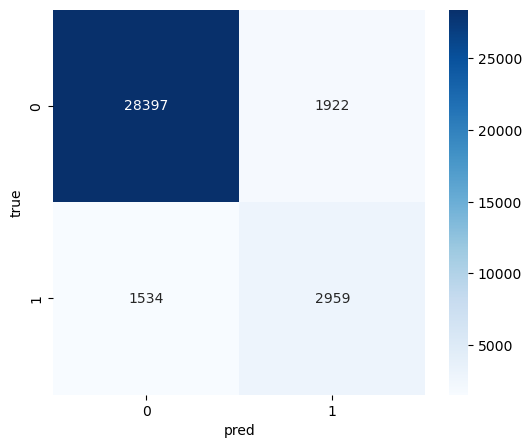

In [4]:
############
# Pred grav avec nb_accident catégories regroupées (1+2 vs 3+4)
# GAT 3 couches
#############

# ════════════════════════════════════════════════════════════
# 0)  LIBRAIRIES & CHARGEMENT
# ════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, torch, torch.nn.functional as F
from torch import nn
from torch_geometric.data import Data
from torch_geometric.transforms import RandomNodeSplit
from torch_geometric.nn import GATConv, BatchNorm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from collections import defaultdict
import geopandas as gpd                    # pour la distance au pôle urbain
from shapely.geometry import Point

# ------------------------------------------------------------------
# 0 a)  DataFrame
# ------------------------------------------------------------------
df = (pd.read_csv("../data/processed/maillage_geo_enriched.csv",
                  low_memory=False, dtype=str)
        .apply(pd.to_numeric, errors="ignore"))

df = df.drop(columns=["com",
                      "surf"])


df["grav"] = df["grav"].astype(int)
df["grav"] = df["grav"].replace(2,1)
df["grav"] = df["grav"].replace(3,2)
df["grav"] = df["grav"].replace(4,2)


# ------------------------------------------------------------------
# 0 b)  Coords + cible
# ------------------------------------------------------------------
DEC = 4                                    # même valeur que lors du maillage
df[["lat10","lon10"]] = df["cell_id"].str.split("_",expand=True).astype(int)
df["lat_deg"] = df["lat10"] / 10**DEC
df["lon_deg"] = df["lon10"] / 10**DEC

y_all = df["grav"].values - 1         # 0 based  (N,)

# ════════════════════════════════════════════════════════════
# 1)  SPLIT  (pré leakage safe)
# ════════════════════════════════════════════════════════════
train_idx, temp_idx = train_test_split(np.arange(len(df)),
                                       test_size=0.30,
                                       stratify=y_all,
                                       random_state=42)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.5,
                                       stratify=y_all[temp_idx],
                                       random_state=42)

train_idx = train_idx.tolist()
val_idx   = val_idx.tolist()
test_idx  = test_idx.tolist()

mask_train = torch.zeros(len(df), dtype=torch.bool)
mask_val   = torch.zeros(len(df), dtype=torch.bool)
mask_test  = torch.zeros(len(df), dtype=torch.bool)

mask_train[train_idx] = True
mask_val  [val_idx]   = True
mask_test [test_idx]  = True

# ════════════════════════════════════════════════════════════
# 2)  FEATURES  (→ X_num, X_cat, features spatiales)
# ════════════════════════════════════════════════════════════
# ------------------------------------------------------------------
# 2 a) coordonnées centrées / réduites (aucune fuite)
# ------------------------------------------------------------------
sc_coord = StandardScaler().fit(df.loc[train_idx,["lat_deg","lon_deg"]])
df[["lat_norm","lon_norm"]] = sc_coord.transform(df[["lat_deg","lon_deg"]])

# ------------------------------------------------------------------
# 2 c) liste finale des colonnes
# ------------------------------------------------------------------
num_cols = ["vma","TMJA","lat_norm","lon_norm","nb_accidents","dist_hop_m","dist_fire_m"]
cat_cols = ['lit','dep','agg','catr','obs','obsm','situ','prof','plan','infra','circ','int',"bridge","tunnel","traffic_calming"]

scaler = StandardScaler().fit(df.loc[train_idx, num_cols])
ohe    = OneHotEncoder(handle_unknown="ignore", sparse_output=False
                      ).fit(df.loc[train_idx, cat_cols].astype(str))

X_num = scaler.transform(df[num_cols])
X_cat = ohe.transform(df[cat_cols].astype(str))
X_tab = np.hstack([X_num, X_cat]).astype(np.float32, copy=False)

# ════════════════════════════════════════════════════════════
# 3)  VOISINAGE 8 connexe ➜ edge_index
# ════════════════════════════════════════════════════════════
coords = df[["lat10","lon10"]].values
index_by_cell = defaultdict(list)
for idx,(la,lo) in enumerate(coords):
    index_by_cell[(la,lo)].append(idx)

edges=[]
for (la,lo),nodes in index_by_cell.items():
    for dlat,dlon in [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]:
        neigh=(la+dlat,lo+dlon)
        if neigh in index_by_cell:
            for i in nodes:
                for j in index_by_cell[neigh]:
                    edges.append([i,j])
edge_index = torch.tensor(edges,dtype=torch.long).t().contiguous()

# ════════════════════════════════════════════════════════════
# 4)  Target Encoding « com »
# ════════════════════════════════════════════════════════════
#te = TargetEncoder(smoothing=10, min_samples_leaf=100)
#te.fit(df.loc[train_idx,"com"], df.loc[train_idx,"grav"])
#com_te = te.transform(df["com"]).values.astype("float32").reshape(-1,1)

# concat features   (sans .numpy())
x_tensor = torch.cat([
        torch.tensor(X_tab.tolist(), dtype=torch.float32)#,
#        torch.tensor(com_te.tolist(), dtype=torch.float32)
], dim=1)
y_tensor = torch.tensor(y_all.tolist(), dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor,
            train_mask=mask_train, val_mask=mask_val, test_mask=mask_test)

print("✅  Graph final :", data)

# ════════════════════════════════════════════════════════════
# 5)  Focal Loss
# ════════════════════════════════════════════════════════════
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):       # γ = 1.5 ici
        super().__init__(); self.gamma=gamma
    def forward(self, logits, targets):
        logp = F.log_softmax(logits, dim=1)
        p    = torch.exp(logp)
        return F.nll_loss((1-p)**self.gamma * logp, targets)

# ════════════════════════════════════════════════════════════
# 6)  GAT (32 têtes, + features spatiales)
# ════════════════════════════════════════════════════════════
class GATResNet(nn.Module):
    def __init__(self, in_dim, hidden=32, out_dim=2, heads=8, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.gats = nn.ModuleList([
            GATConv(in_dim, hidden, heads=heads, dropout=dropout),
            GATConv(hidden * heads, hidden, heads=heads, dropout=dropout),
            GATConv(hidden * heads, hidden, heads=heads, dropout=dropout),
        ])
        self.bns = nn.ModuleList([
            BatchNorm(hidden * heads),
            BatchNorm(hidden * heads),
            BatchNorm(hidden * heads),
        ])
        self.res0 = nn.Linear(in_dim, hidden * heads, bias=False)
        self.final = GATConv(hidden * heads, out_dim, heads=1, concat=False)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h = self.gats[0](x, ei)
        h = F.elu(self.bns[0](h))
        x = self.res0(x) + h
        x = F.dropout(x, p=self.dropout, training=self.training)
        for gat, bn in zip(self.gats[1:], self.bns[1:]):
            h = F.elu(bn(gat(x, ei)))
            x = x + h
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.final(x, ei)

device = torch.device("cpu")  # ou 'cuda' / 'mps'

model = GATResNet(
    in_dim   = data.x.size(1),
    hidden   = 32,     # même largeur qu’avant
    out_dim  = int(data.y.max()) + 1,
    heads    = 8,      # ↓ têtes
    dropout  = 0.1
).to(device)

data = data.to(device)

criterion = FocalLoss(gamma=1.5)
#criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.,3]))
opt  = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)  #1e-4
sched= torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)

def step(mask, update=False):
    model.train(update)
    opt.zero_grad()
    out  = model(data)[mask]
    loss = criterion(out, data.y[mask])
    if update:
        loss.backward(); opt.step()
    acc  = (out.argmax(1)==data.y[mask]).float().mean().item()
    return loss.item(), acc

for epoch in range(1,101):
    loss_tr,_ = step(data.train_mask, update=True)
    if epoch%10==0:
        _,acc_tr = step(data.train_mask)
        loss_va,acc_va = step(data.val_mask)
        sched.step(loss_va)
        print(f"E{epoch:03d}  tr_loss {loss_tr:.3f}  tr_acc {acc_tr:.3f}  val_acc {acc_va:.3f}")

_,acc_test = step(data.test_mask)
print(f"\n🎯  Test accuracy : {acc_test:.3f}")

# ════════════════════════════════════════════════════════════
# 6 bis)  choisit le seuil optimal sur le jeu de validation
# ════════════════════════════════════════════════════════════
model.eval()
with torch.no_grad():
    logits_val = model(data)[data.val_mask]
    probas_val = logits_val.softmax(1)[:, 1].cpu().tolist()   # p(classe 1)
    y_val      = data.y[data.val_mask].cpu().tolist()

from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_val, probas_val)

# Si on veut maximiser la F1 :

f1   = 2 * prec * rec / (prec + rec + 1e-9)
best = f1.argmax()
best_thr = thr[best] if best < len(thr) else 0.5
print(f"🔎 Seuil F1‑max : {best_thr:.2f}  (F1={f1[best]:.3f})")

# Si on veut maximiser la precision :

#prec   = prec[1:]
#rec    = rec[1:]
#thr    = thr            # même taille que prec/rec maintenant

# (option) garder un rappel minimum, ex. > 0.10
#mask   = rec > 0.30
#best_i = np.argmax(prec[mask])
#best_thr = thr[mask][best_i]

#print(f"Seuil max‑precision (recall>10 %) : {best_thr:.3f} "
#      f"precision={prec[mask][best_i]:.2f}  recall={rec[mask][best_i]:.2f}")

# ════════════════════════════════════════════════════════════
# 7)  MATRICE DE CONFUSION
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    logits_test = model(data)[data.test_mask]
    probas_test = logits_test.softmax(1)[:, 1].cpu().tolist()
    preds       = (probas_test > best_thr).astype(int)      # ← seuil validé
    true        = data.y[data.test_mask].cpu().tolist()

print(classification_report(true, preds))
cm = confusion_matrix(true, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("pred"); plt.ylabel("true"); plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3074
[LightGBM] [Info] Number of data points in the train set: 185664, number of used features: 191
[LightGBM] [Info] Start training from score 0.205826
R² proxy : 0.9854912252496756


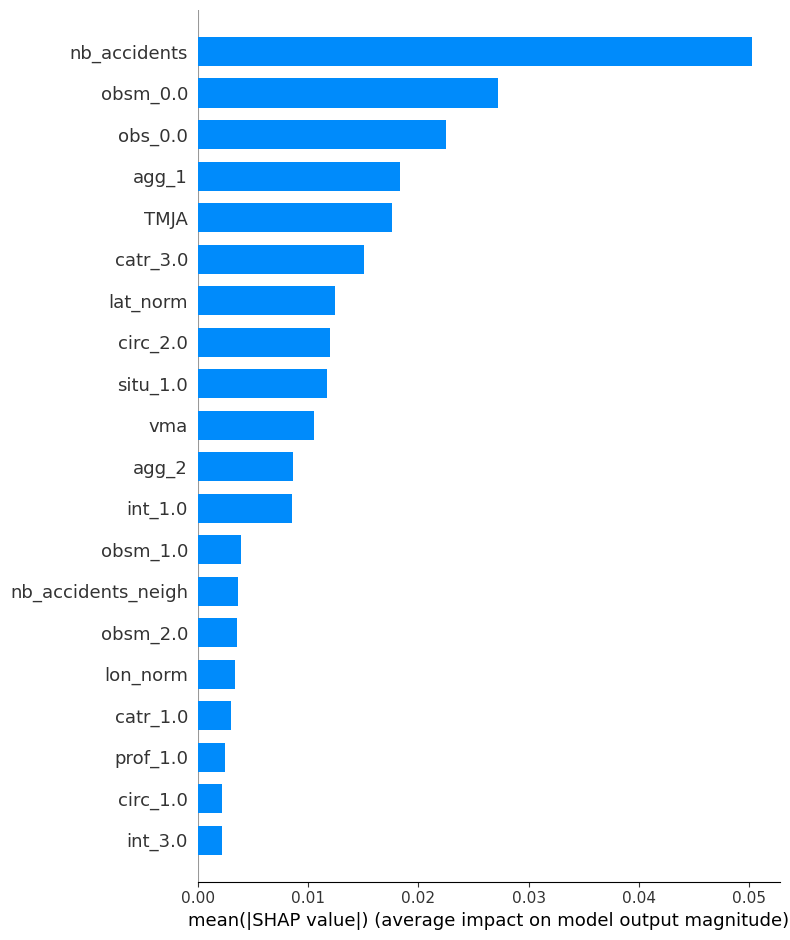

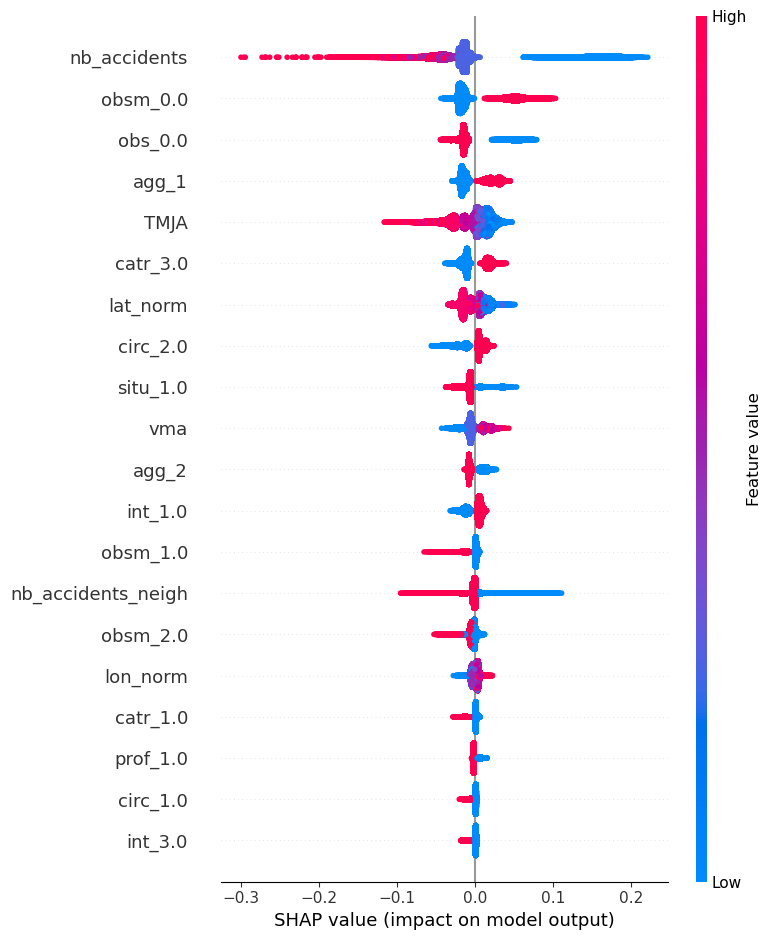

In [5]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler

# ---- features du nœud -------------------------------------------------
df_flat = pd.DataFrame(data.x.cpu().tolist(), columns=[
        *num_cols,                               # vma, TMJA, …
        *ohe.get_feature_names_out(cat_cols),    # lit_no, situ_1.0, …
        
])



# ---- voisinage (moyenne des features continues) ----------------------
# edge_index : [2, E]
src, dst = data.edge_index.cpu().tolist()
nbrs = [[] for _ in range(len(df_flat))]
for s, d in zip(src, dst):
    nbrs[d].append(s)          # in-neighbors

for col in num_cols:
    neigh_mean = [
        df_flat.loc[idxs, col].mean() if idxs else np.nan
        for idxs in nbrs
    ]
    df_flat[f"{col}_neigh"] = neigh_mean

# valeurs NA → moyenne globale
df_flat = df_flat.fillna(df_flat.mean())

with torch.no_grad():
    proba_gnn = model(data).softmax(1)[:, 1].cpu().numpy()  # (N,)
y_reg = proba_gnn   # régression sur [0,1]

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_flat, y_reg, test_size=0.2, random_state=42)

lgb = LGBMRegressor(
    n_estimators=600,
    max_depth=-1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
).fit(X_train, y_train)

print("R² proxy :", lgb.score(X_test, y_test))

import shap
explainer = shap.TreeExplainer(lgb)
shap_values = explainer.shap_values(df_flat, check_additivity=False)  # (N, F)

shap.summary_plot(shap_values, df_flat, plot_type="bar")

shap.summary_plot(shap_values, df_flat)   # beeswarm


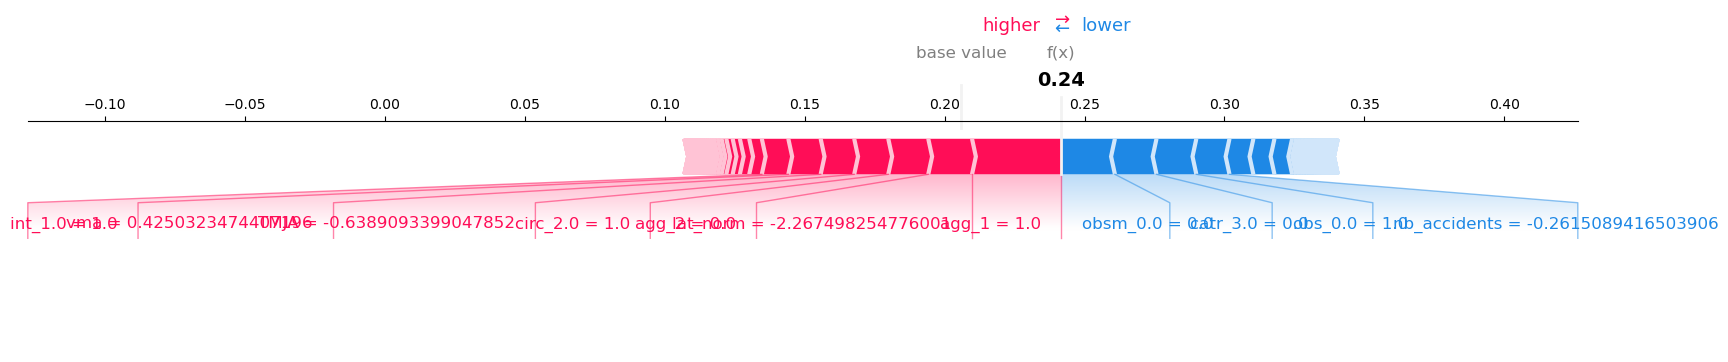

In [6]:
# Visualisation d'un tronçon random

import random
chosen_idx = random.randint(0, data.num_nodes - 1)

shap.force_plot(
    explainer.expected_value,
    shap_values[chosen_idx],
    df_flat.iloc[chosen_idx],
    matplotlib=True
)

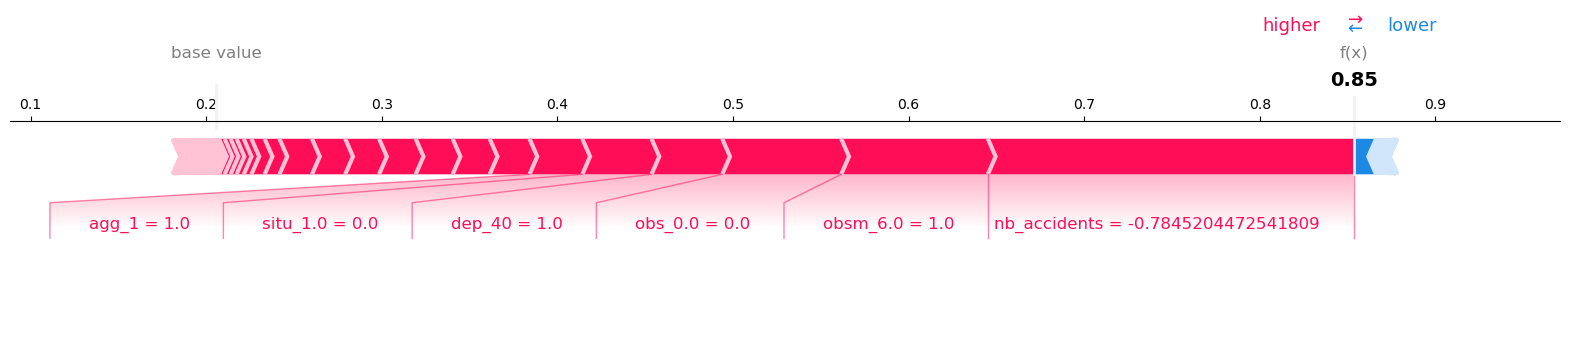

In [8]:
# Visualisation du tronçon avec la plus grande gravité

with torch.no_grad():
    proba = model(data).softmax(dim=1)[:, 1].cpu().numpy()

chosen_idx = proba.argmax()  # le tronçon le plus grave selon le modèle

shap.force_plot(
    explainer.expected_value,
    shap_values[chosen_idx],
    df_flat.iloc[chosen_idx],
    matplotlib=True
)

In [9]:
import joblib

joblib.dump(model, "../models/GAT.joblib")
joblib.dump(shap_values, "../models/shap_values.joblib")
joblib.dump(explainer, "../models/explainer.joblib")

torch.save(data.cpu(), "../models/graph_data.pt")

df.to_csv("../data/processed/GAT_df.csv", index=False)
joblib.dump(ohe, "../models/ohe.joblib")
joblib.dump(best_thr, "../models/best_thr.joblib")


['../models/best_thr.joblib']